# ImageEditor notebook-first demo

This notebook is the first client of `ImageProcessor`. Wire the SAM3 adapter before running segmentation; FLUX Fill is loaded lazily on the first edit.

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image
from IPython.display import display

from inpaint_core import ImageProcessor, PointPrompt, MaskOptions, GenerationOptions, preprocess_image

In [ ]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
processor = ImageProcessor.from_config(PROJECT_ROOT / 'configs' / 'default.yaml')
processor

## Load an image

In [ ]:
IMAGE_PATH = PROJECT_ROOT / 'assets' / 'examples' / 'replace-with-an-image.jpg'
image = preprocess_image(IMAGE_PATH)
display(Image.fromarray(image))

## Segment once, inspect candidates, then reuse the selected mask

In [ ]:
selection = PointPrompt(points=[(500, 300)], labels=[1])
segments = processor.segment(image, selection)
mask = segments.best_mask
display(Image.fromarray(mask))

## Object removal

In [ ]:
removed = processor.remove_object(
    image,
    mask=mask,
    mask_options=MaskOptions(dilate=12, feather=6, crop_padding=128),
)
display(Image.fromarray(removed.image))
removed.metadata
processor.memory_tracker.save_json(PROJECT_ROOT / 'outputs' / 'debug' / 'memory-stats.json')

## Object replacement

In [ ]:
replaced = processor.replace_object(
    image,
    'a small white ceramic vase matching the scene lighting',
    mask=mask,
    generation_options=GenerationOptions(seed=42),
)
display(Image.fromarray(replaced.image))

## Background replacement

In [ ]:
background = processor.replace_background(
    image,
    'a quiet tropical beach at sunset',
    foreground_mask=mask,
    mask_options=MaskOptions(dilate=0, feather=6, crop_padding=0),
)
display(Image.fromarray(background.image))

Image shape: (1282, 960, 3)
Center point: (480, 641)


/home/phuong/miniforge3/envs/imageinpaint/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Number of masks: 3
Scores: [0.9921875, 0.515625, 0.87890625]
Best mask: 0
Mask 0 | score=0.9922 | BEST


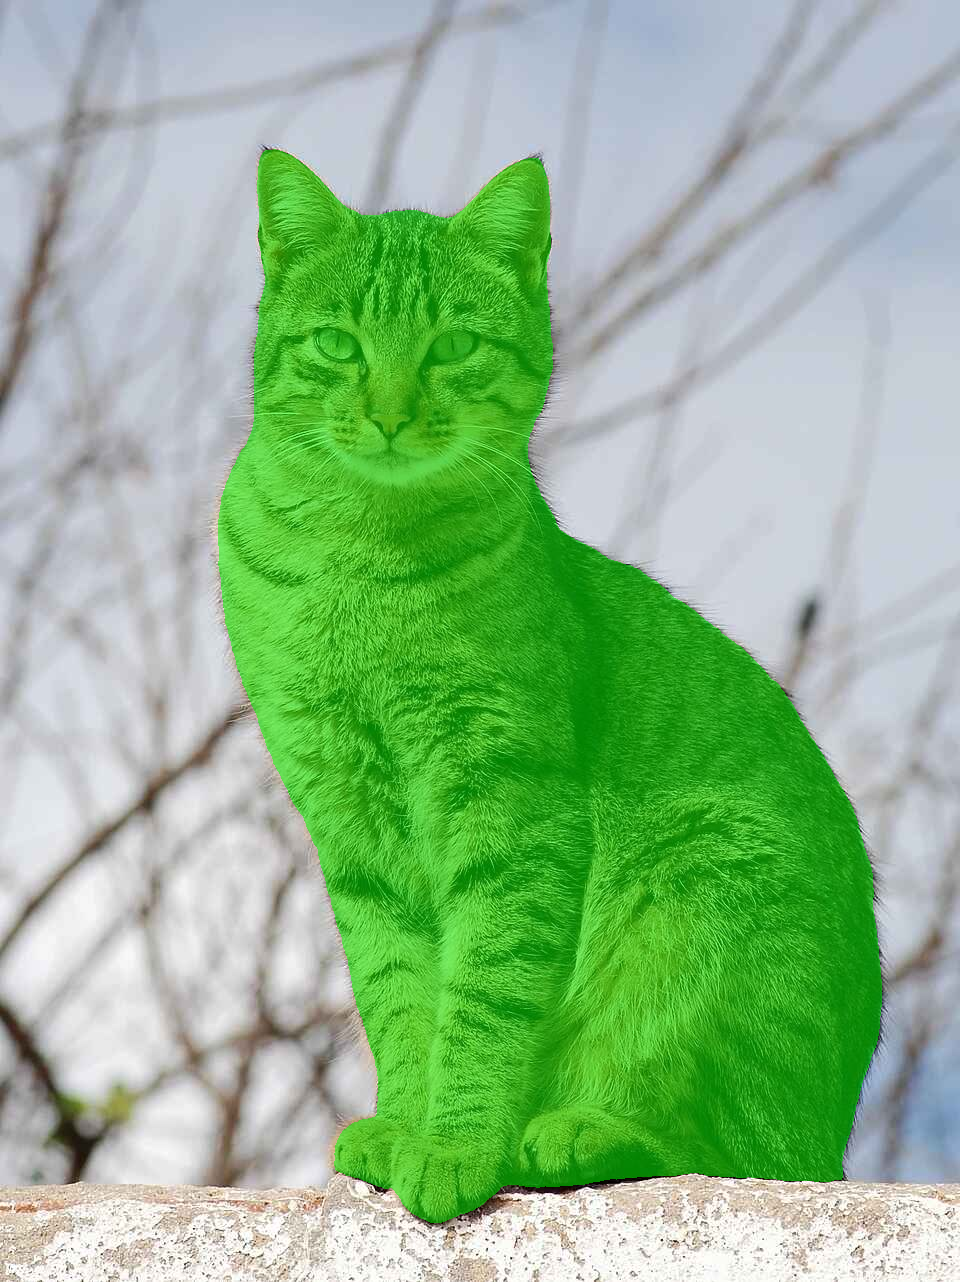

Mask 1 | score=0.5156


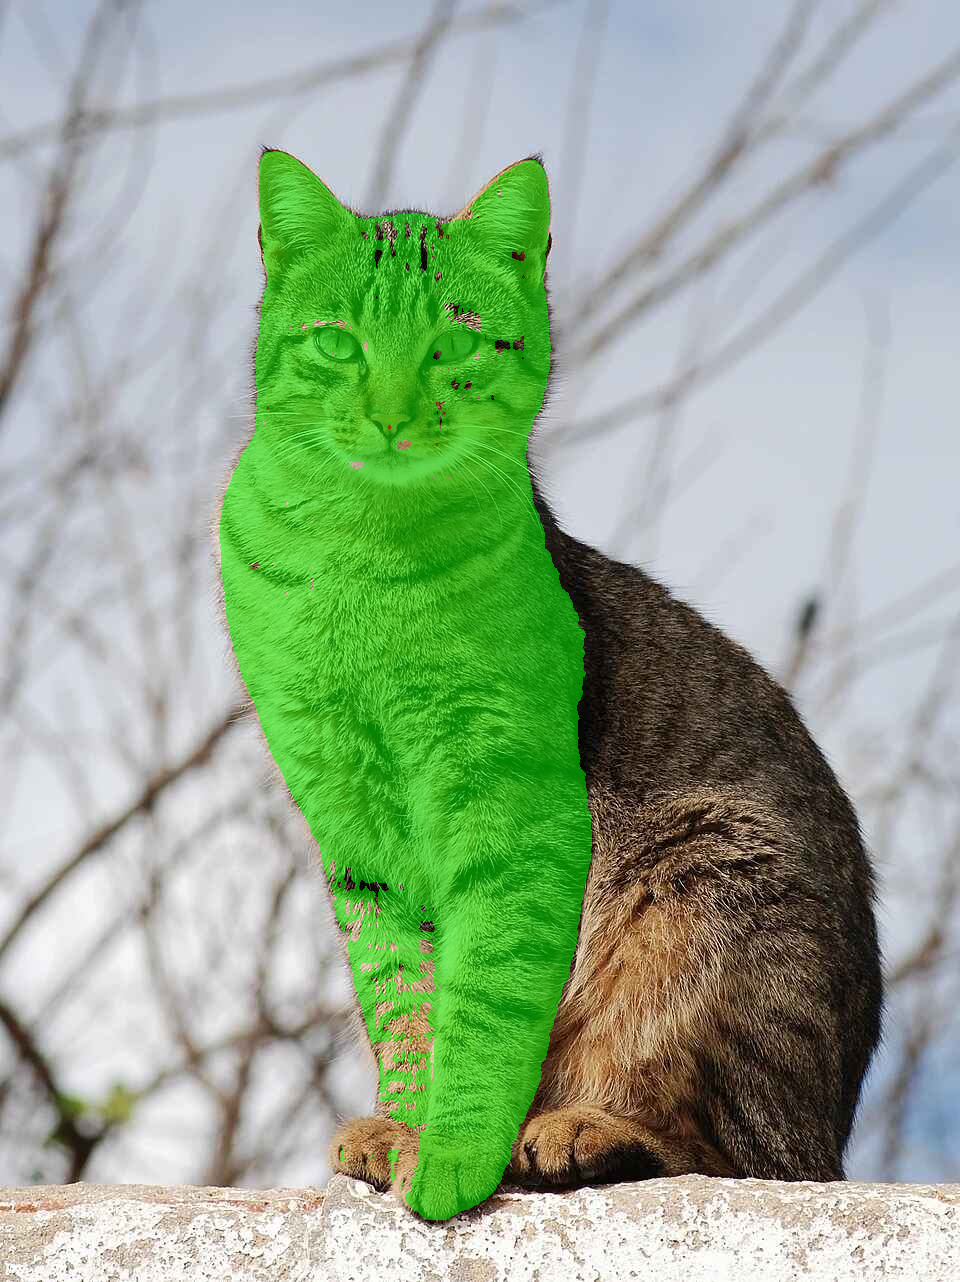

Mask 2 | score=0.8789


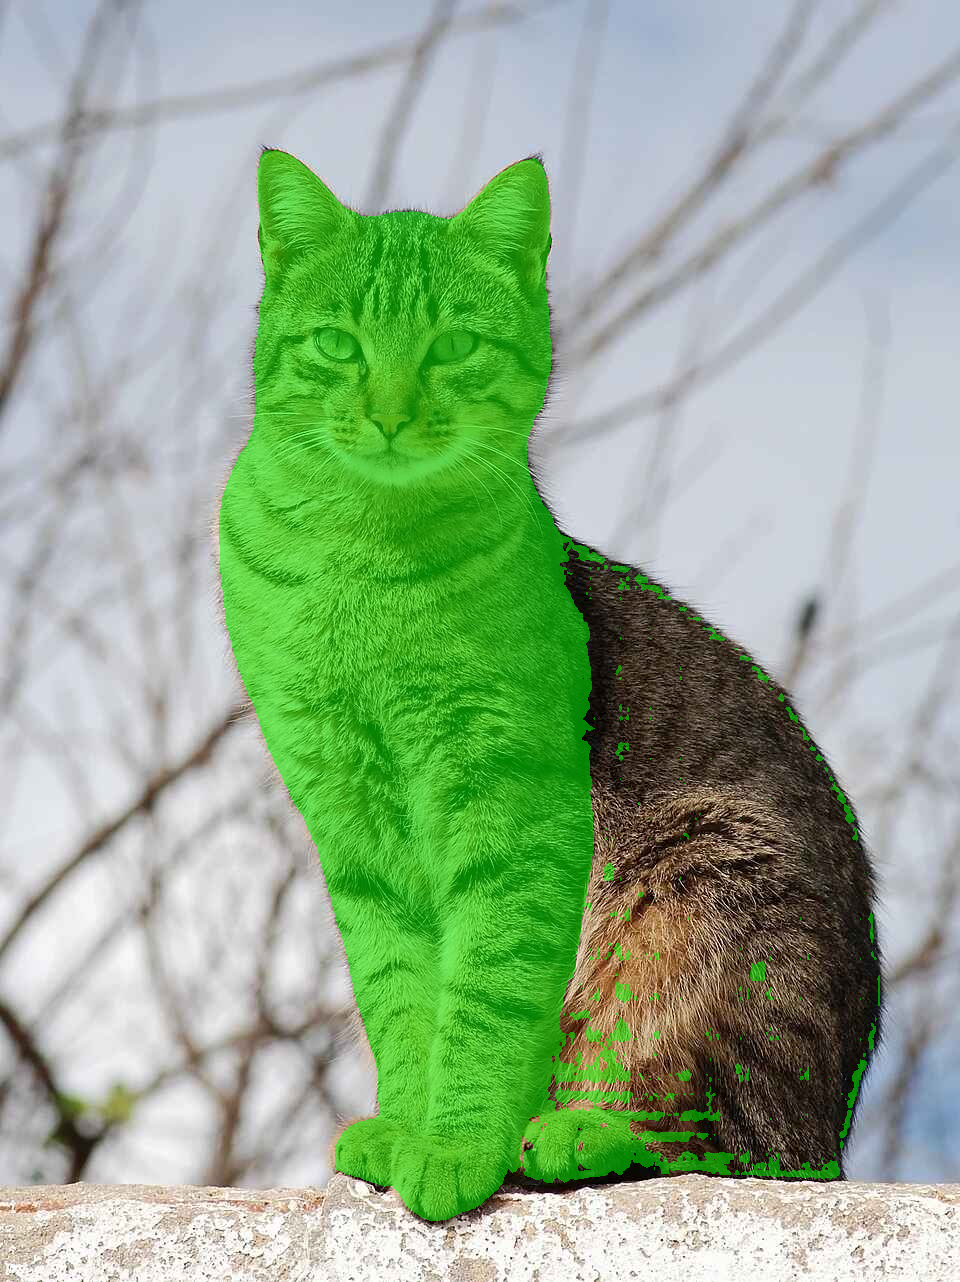

In [3]:
from pathlib import Path

import numpy as np
from PIL import Image
from IPython.display import display

from inpaint_core import ImageProcessor, PointPrompt, preprocess_image

root = Path.cwd()
image = preprocess_image(root / "assets" / "cat.jpg")

height, width = image.shape[:2]
center_point = (width // 2, height // 2)

print("Image shape:", image.shape)
print("Center point:", center_point)

processor = ImageProcessor.from_config(
    root / "configs" / "default.yaml"
)

result = processor.segment(
    image,
    PointPrompt(
        points=[center_point],
        labels=[1],
    ),
)

print("Number of masks:", len(result.masks))
print("Scores:", result.scores)
print("Best mask:", result.best_index)

for index, (mask, score) in enumerate(zip(result.masks, result.scores)):
    overlay = image.copy()
    selected = mask > 0

    color = np.array([0, 255, 0], dtype=np.uint8)
    overlay[selected] = (
        overlay[selected].astype(np.float32) * 0.5
        + color.astype(np.float32) * 0.5
    ).astype(np.uint8)

    print(
        f"Mask {index} | score={score:.4f}"
        + (" | BEST" if index == result.best_index else "")
    )
    display(Image.fromarray(overlay))